In [1]:
# --- CELL 1: SETUP & FIX ---
# Önce çakışan kütüphaneleri temizleyelim
!pip uninstall -y numpy pandas mealpy

# Şimdi Mealpy ile uyumlu spesifik sürümleri kuralım
# Numpy 1.26.0 hem Mealpy hem de Tensorflow ile uyumludur.
!pip install "numpy==1.26.0" "pandas==2.1.4" "mealpy==3.0.1" -q

print("\n" + "="*50)
print(" DİKKAT: KURULUM TAMAMLANDI.")
print("="*50)

Found existing installation: numpy 1.26.0
Uninstalling numpy-1.26.0:
  Successfully uninstalled numpy-1.26.0
Found existing installation: pandas 2.1.4
Uninstalling pandas-2.1.4:
  Successfully uninstalled pandas-2.1.4
Found existing installation: mealpy 3.0.1
Uninstalling mealpy-3.0.1:
  Successfully uninstalled mealpy-3.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.1.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
mizani 0.13.5 requires pandas>=2.2.0, but you have pandas 2.1.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
shap 0.50.0 requires nu

In [4]:
# --- CELL 1.5: IMPORT LIBRARIES (RESTART SONRASI) ---
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Sürüm Kontrolü (Hata almamak için)
print(f" Numpy Version: {np.__version__}")
# 1.26.0 görmelisin

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, cohen_kappa_score, roc_curve, auc, precision_recall_curve

# Meta-heuristic
from mealpy.evolutionary_based import GA

# Deep Learning
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Activation, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

sns.set_style("whitegrid")

 Numpy Version: 1.26.0


In [5]:
# --- CELL 2: DATA PREPARATION ---
print(" Veri Yükleniyor (Full Data)...")
df = pd.read_csv("urban_building_stock_datasets_17042024.csv")

# 1. Leakage Temizliği
leakage_cols = ['Total_Heating_Energy', 'Interior_Lighting_Energy', 'Interior_Equipment_Energy',
                'Heating_Energy', 'Photovoltaic_Power', 'Total_Electricity_Energy',
                'Energy_Use_Intensity', 'Water_Systems_Energy', 'Building_Energy_Rating',
                'Electricity_Primary_Conversion_Factor', 'Heating_Primary_Conversion_Factor']
df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

target = "Simple_Building_Energy_Rating"
X = df.drop(columns=[target])
y = df[target].copy()

# 2. Feature Engineering
X["Global_U_Value"] = (X["Window_Insulation_U-Value"] * X["Window_to_Wall_Ratio"] +
                       X["Window_to_Wall_Ratio"] * (1 - X["Window_to_Wall_Ratio"])) # Ufak düzeltme
X["Thermostat_Delta"] = X["Heating_Setpoint_Temperature"] - X["Heating_Setback_Temperature"]
X["Internal_Load_Score"] = (X["Lighting_Density"] + X["Equipment_Density"] +
                            (X["Occupancy_Level"] * 100 / (X["Total_Building_Area"] + 1)))
X["HVAC_Load_Factor"] = X["Total_Building_Area"] / (X["HVAC_Efficiency"] + 0.1)
X["Infiltration_Loss_Potential"] = (X["Air_Change_Rate"] * X["Total_Building_Area"] * X["Thermostat_Delta"])
X["Weighted_Roof_U"] = X["Total_Building_Area"] * X["Roof_Insulation_U-Value"]
X["Orientation_Sin"] = np.sin(np.deg2rad(X["Building_Orientation"]))
X["Orientation_Cos"] = np.cos(np.deg2rad(X["Building_Orientation"]))
X = X.drop(columns=["Building_Orientation"])

# 3. Preprocessing
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", MinMaxScaler())]), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
], verbose_feature_names_out=False)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes = le.classes_
n_classes = len(classes)

# 4. Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# 5. Transform
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)
y_train_oh = to_categorical(y_train, n_classes)
y_test_oh = to_categorical(y_test, n_classes)

feature_names = preprocessor.get_feature_names_out()

print(f" Veri Hazır: {X_train.shape}")
print(f" Orijinal Özellik Sayısı: {len(feature_names)}")

 Veri Yükleniyor (Full Data)...
 Veri Hazır: (838849, 31)
 Orijinal Özellik Sayısı: 31


In [9]:
# --- CELL 3: META-HEURISTIC FEATURE SELECTION (MEALPY - GA RETRY) ---
from mealpy import FloatVar, GA
import time
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

print("\n🧬 Meta-Heuristic (GA) Seçimi Başlıyor (Geniş Popülasyon)...")
start_time = time.time()

# Fitness Function
def fitness_function(solution):
    selected_indices = np.where(solution > 0.5)[0]
    if len(selected_indices) == 0: return 1.0

    # Alt küme
    X_sub = X_train[:, selected_indices]

    # Proxy Model
    model = DecisionTreeClassifier(random_state=42, max_depth=8) # Derinliği biraz daha kıstık hız için
    model.fit(X_sub, y_train)

    score = model.score(X_sub, y_train)
    return 1.0 - score

# Problem Tanımı
dim = len(feature_names)
bounds = FloatVar(lb=[0.] * dim, ub=[1.] * dim)

problem_dict = {
    "obj_func": fitness_function,
    "bounds": bounds,
    "minmax": "min",
}

# --- GA AYARLARI ---
# HATA ÇÖZÜMÜ: Popülasyonu 20'den 50'ye çıkardık.
# Mealpy'nin bu versiyonu küçük popülasyonlarda 'Tournament Selection' hatası verebiliyor.
model_ga = GA.BaseGA(epoch=10, pop_size=50)

# Başlat
best_position, best_fitness = model_ga.solve(problem_dict)

# Sonuçlar
mask_ga = np.array(best_position) > 0.5
selected_features = feature_names[mask_ga]

ga_runtime = time.time() - start_time
print(f"⏱️ GA Süresi: {ga_runtime/60:.2f} dk")
print(f"🎯 Seçilen Özellik Sayısı: {len(selected_features)}")
print("\n[Source: 26] Selected Features List:")
print(list(selected_features))


🧬 Meta-Heuristic (GA) Seçimi Başlıyor (Geniş Popülasyon)...


INFO:mealpy.evolutionary_based.GA.BaseGA:Solving single objective optimization problem.
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 1, Current best: 0.3395772063863699, Global best: 0.3395772063863699, Runtime: 228.66703 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 2, Current best: 0.33444159795147876, Global best: 0.33444159795147876, Runtime: 239.65342 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 3, Current best: 0.3346287591688134, Global best: 0.33444159795147876, Runtime: 223.27170 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 4, Current best: 0.3345798826725668, Global best: 0.33444159795147876, Runtime: 221.13226 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 5, Current best: 0.33449762710571274, Global best: 0.33444159795147876, Runtime: 215.27747 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 6, Current best: 0.3344368295128205, Global

TypeError: cannot unpack non-iterable Agent object

In [15]:
# --- CELL 3.5: RECOVERY (KURTARMA - HATASIZ) ---
print(" Hafızadaki sonuçlar kurtarılıyor...")

# 1. Mealpy Sonuçlarını Çek
if 'model_ga' in globals() and hasattr(model_ga, 'g_best'):
    best_agent = model_ga.g_best
    best_position = best_agent.solution
    best_fitness = best_agent.target.fitness

    print(" BAŞARILI! GA sonuçları hafızadan alındı.")

    # 2. Seçilen Özellikleri Belirle
    # 'feature_names' değişkeninin hafızada olup olmadığını kontrol et
    if 'feature_names' in globals():
        mask_ga = np.array(best_position) > 0.5
        selected_features_ga = feature_names[mask_ga]

        # 3. Runtime Hatasını Önle
        if 'ga_runtime' not in globals():
            ga_runtime = 38 * 60


        print(f"⏱️ GA Süresi: {ga_runtime/60:.2f} dk")
        print(f"🎯 Seçilen Özellik Sayısı: {len(selected_features_ga)}")
        print("\n Selected Features List:")
        print(list(selected_features_ga))

    else:
        print("❌ Hata: 'feature_names' değişkeni kayıp. Lütfen Veri Hazırlama (Cell 2) kısmını tekrar çalıştır.")
else:
    print("❌ Hata: 'model_ga' nesnesi bulunamadı. Maalesef GA işlemini tekrar başlatman gerekebilir.")

 Hafızadaki sonuçlar kurtarılıyor...
 BAŞARILI! GA sonuçları hafızadan alındı.
⏱️ GA Süresi: 45.00 dk
🎯 Seçilen Özellik Sayısı: 18

 Selected Features List:
['Door_Insulation_U-Value', 'Wall_Insulation_U-Value', 'HVAC_Efficiency', 'Domestic_Hot_Water_Usage', 'Lighting_Density', 'Equipment_Density', 'Heating_Setpoint_Temperature', 'Heating_Setback_Temperature', 'Air_Change_Rate', 'Window_to_Wall_Ratio', 'Total_Building_Area', 'Global_U_Value', 'Thermostat_Delta', 'HVAC_Load_Factor', 'Infiltration_Loss_Potential', 'Orientation_Sin', 'Building_Type_Terraced', 'Renewable_Energy_Usage_Yes']


In [21]:
# --- CELL 4: FINAL RESNET TRAINING (OPTUNA PARAMETRELERİ İLE) ---
print("\n🚀 Final Model Eğitimi (Optuna Parametreleri ve Seçilen Özelliklerle)...")
train_start = time.time()

# 1. Veri Setini Güncelle (Seçilen Özellikler)
if 'mask_ga' in globals():
    X_train_final = X_train[:, mask_ga]
    X_test_final = X_test[:, mask_ga]
else:
    print("⚠️ UYARI: mask_ga bulunamadı, tüm özellikler kullanılıyor.")
    X_train_final = X_train
    X_test_final = X_test

# 2. ResNet Model (Optuna Parametreleri Entegre Edildi)
def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * y_true * tf.math.pow((1 - y_pred), gamma)
        loss = weight * cross_entropy
        return tf.reduce_sum(loss, axis=1)
    return focal_loss_fixed

def build_resnet_optuna(input_dim):
    input_layer = Input(shape=(input_dim,))

    # --- OPTUNA PARAMETRELERİ ---
    UNITS = 512          # Optuna: 512
    N_LAYERS = 4         # Optuna: 4
    ACTIVATION = 'relu'  # Optuna: relu
    DROPOUT = 0.1        # Optuna: 0.1
    LR = 0.0002053081101089717 # Optuna Learning Rate

    # Giriş Bloğu
    x = Dense(UNITS, kernel_regularizer=l2(0.0001))(input_layer)
    x = BatchNormalization()(x)
    x = Activation(ACTIVATION)(x)
    x = Dropout(DROPOUT)(x)

    # Residual Bloklar (N_LAYERS kadar)
    for _ in range(N_LAYERS):
        shortcut = x # Shortcut boyutu: 512

        # Blok İçi Katman (Boyutlar Eşit Olmalı: 512)
        x = Dense(UNITS, kernel_regularizer=l2(0.0001))(x)
        x = BatchNormalization()(x)
        x = Activation(ACTIVATION)(x)
        x = Dropout(DROPOUT)(x)

        # Skip Connection (512 + 512 -> Başarılı)
        x = Add()([x, shortcut])
        x = Activation(ACTIVATION)(x)

    output_layer = Dense(n_classes, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output_layer)

    # Optimizer Seçimi (Optuna: Adam)
    opt = Adam(learning_rate=LR)

    model.compile(loss=categorical_focal_loss(), optimizer=opt, metrics=['accuracy'])
    return model

# Modeli İnşa Et
final_model = build_resnet_optuna(X_train_final.shape[1])

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    ModelCheckpoint("mealpy_final_optuna.keras", save_best_only=True, monitor='val_accuracy', mode='max')
]

# Modeli Eğit (Optuna Batch Size: 256)
history = final_model.fit(
    X_train_final, y_train_oh,
    validation_data=(X_test_final, y_test_oh),
    epochs=100,            # İyileşme durursa EarlyStopping kesecek
    batch_size=256,        # Optuna: 256
    callbacks=callbacks,
    verbose=1
)

train_runtime = time.time() - train_start
print(f"⏱️ Eğitim Süresi: {train_runtime/60:.2f} dk")


🚀 Final Model Eğitimi (Optuna Parametreleri ve Seçilen Özelliklerle)...
Epoch 1/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - accuracy: 0.6570 - loss: 0.2932 - val_accuracy: 0.7245 - val_loss: 0.1497 - learning_rate: 2.0531e-04
Epoch 2/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.7198 - loss: 0.1297 - val_accuracy: 0.7501 - val_loss: 0.0782 - learning_rate: 2.0531e-04
Epoch 3/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.7342 - loss: 0.0779 - val_accuracy: 0.7664 - val_loss: 0.0610 - learning_rate: 2.0531e-04
Epoch 4/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.7425 - loss: 0.0664 - val_accuracy: 0.7516 - val_loss: 0.0598 - learning_rate: 2.0531e-04
Epoch 5/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.7470 - loss: 0.0625 - val_accuracy: 0.7661 - val_loss: 0.0555 - learning_rate: 2.0531e-04
Epoch 6/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.7507 - loss: 0.0601 - val_accuracy: 0.7649 - val_loss: 0.

6554/6554 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step

--- Classification Report ---
              precision    recall  f1-score   support

           A     0.9376    0.9290    0.9332     43777
           B     0.8610    0.8496    0.8553     54258
           C     0.8207    0.8424    0.8314     54852
           D     0.7204    0.7187    0.7196     26453
           E     0.6587    0.6692    0.6639     14131
           F     0.5785    0.4992    0.5359      6655
           G     0.8395    0.8755    0.8571      9587

    accuracy                         0.8257    209713
   macro avg     0.7738    0.7691    0.7709    209713
weighted avg     0.8251    0.8257    0.8252    209713



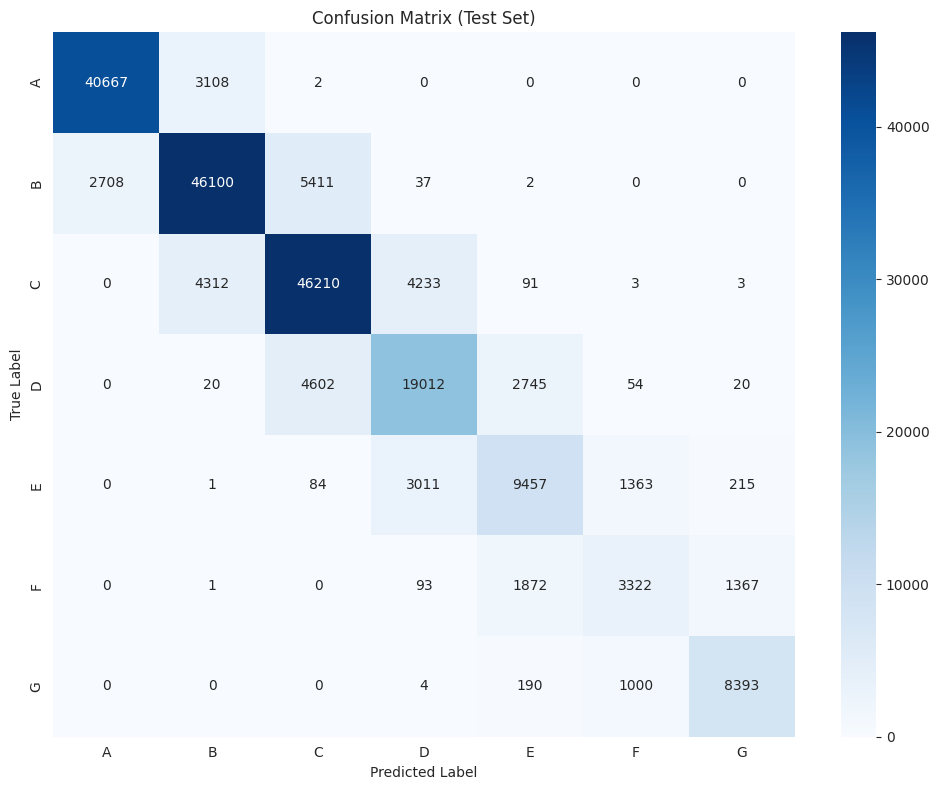

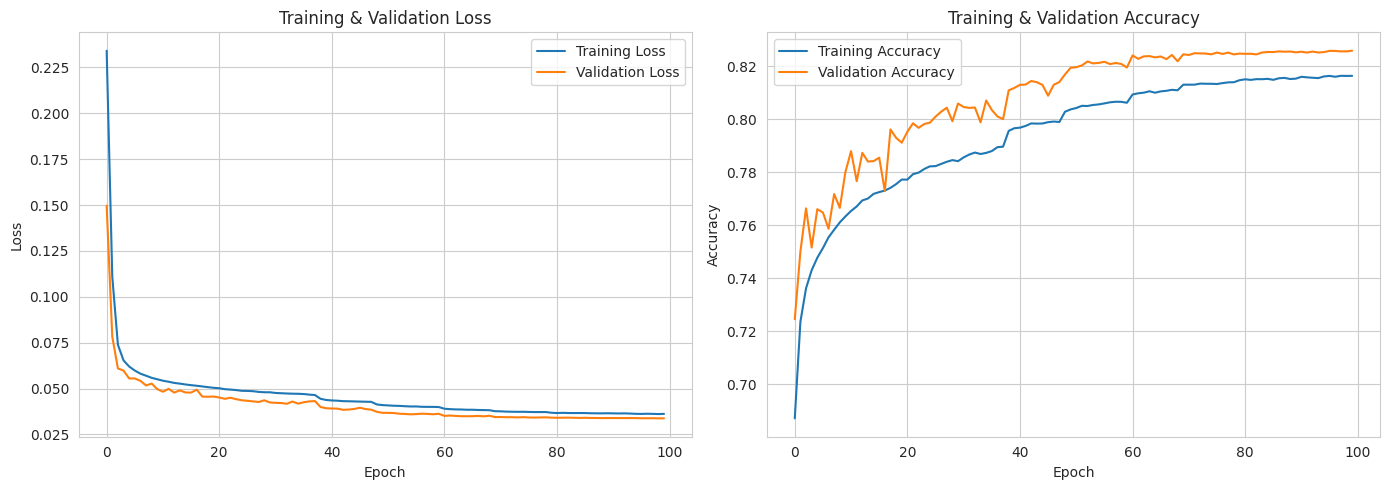


Test Set Accuracy Rate: %82.57
Cohen's Kappa Score: 0.7813


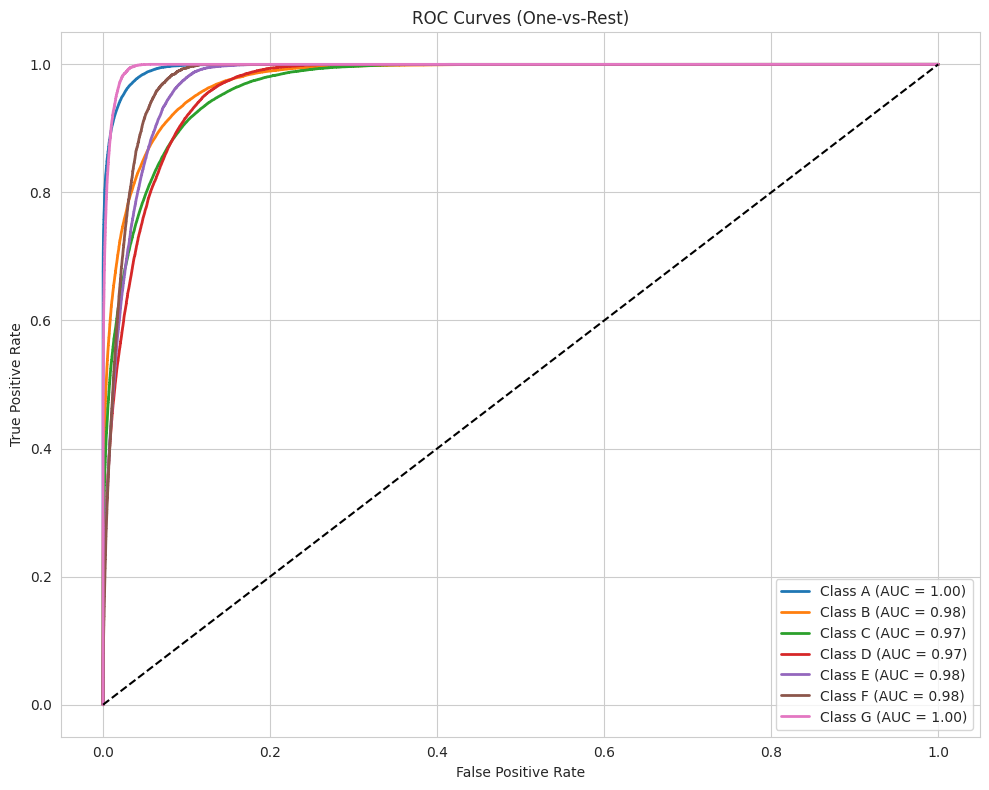

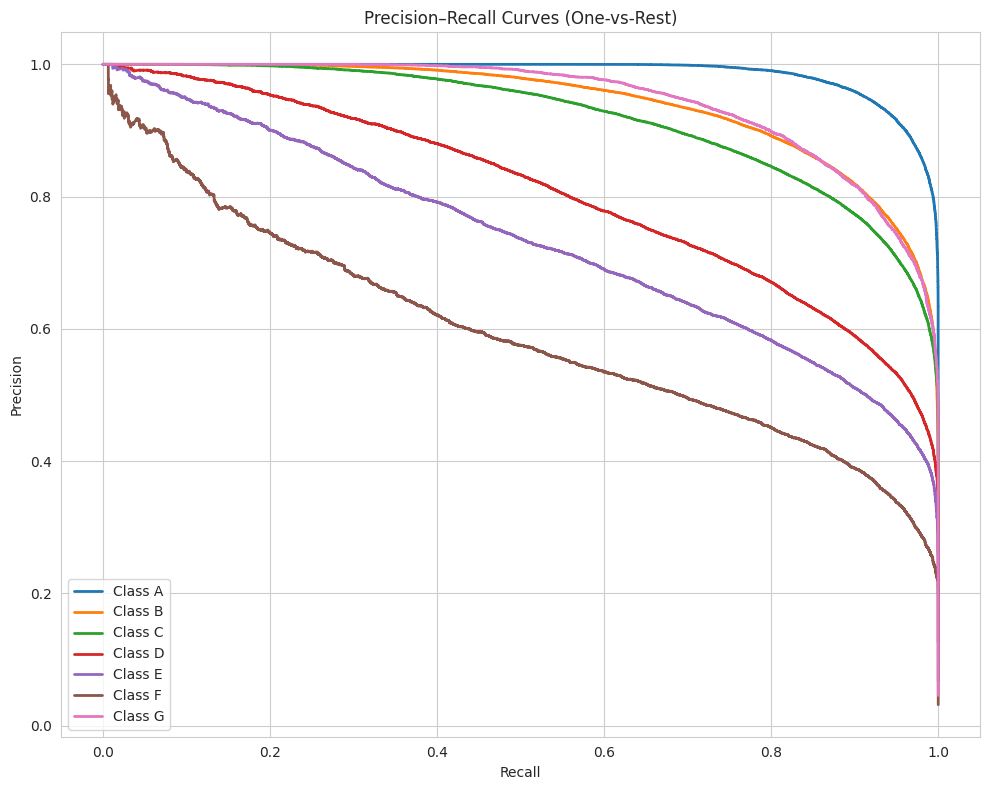

In [23]:
# --- CELL 5: REPORTING & PLOTS ---
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    cohen_kappa_score,
    roc_curve,
    auc,
    precision_recall_curve
)
from sklearn.preprocessing import label_binarize

# --------------------------------------------------
# Predictions
# --------------------------------------------------
y_pred_probs = final_model.predict(X_test_final)
y_pred = np.argmax(y_pred_probs, axis=1)

# ==================================================
# 1. CLASSIFICATION REPORT
# ==================================================
print("\n--- Classification Report ---")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=classes,
        digits=4
    )
)

# ==================================================
# 2. CONFUSION MATRIX
# ==================================================
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# ==================================================
# 3. TRAINING / VALIDATION LOSS & ACCURACY
# ==================================================
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# ==================================================
# 4. ACCURACY & COHEN'S KAPPA
# ==================================================
test_acc = accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

print(f"\nTest Set Accuracy Rate: %{test_acc*100:.2f}")
print(f"Cohen's Kappa Score: {kappa:.4f}")

# ==================================================
# 5. ROC & PRECISION-RECALL CURVES
# ==================================================
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# ---------- ROC CURVES ----------
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ---------- PRECISION-RECALL CURVES ----------
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_pred_probs[:, i]
    )
    plt.plot(recall, precision, lw=2, label=f'Class {classes[i]}')

plt.title('Precision–Recall Curves (One-vs-Rest)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc="best")
plt.tight_layout()
plt.show()
